In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from tracker_log_analysis import *

Datetime object:  2023-11-05 01:01:01+00:00
Unix time in microseconds:  1699146061000000
unique tracks:  [0 1]


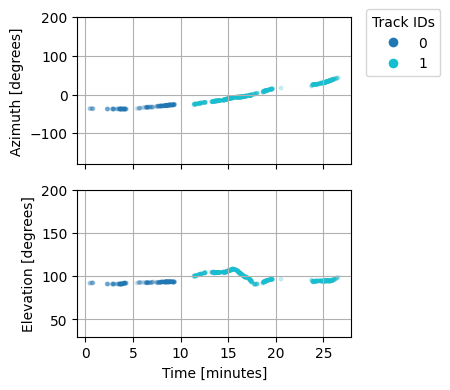

In [2]:
#path_doa = "../listener_program/231105_090101_007440_tracker"
#path_doa = "tracks_old/231105_090101_000000_tracker_164"
#!pwd
path_doa = "../listener_program/deployment_files/231105_010101_000000_tracker"
#path_doa = "../listener_program/deployment_files/231105_010101_778720_tracker"
#path_doa = "tracks/231105_090101_000000_tracker_103"
kalman_log = read_log_csv(path_doa)
#print(kalman_log)
plot_log(path_doa, kalman_log, [])

In [3]:

# Track statistics
import pandas as pd

df = pd.DataFrame(kalman_log, columns=kalman_log[0]._fields)

num_tracks = df['filter_id'].nunique()
print(f"Number of unique tracks detected: {num_tracks}")

track_durations = (
    df.groupby('filter_id')['time']
    .agg(start='min', end='max')
    .assign(duration_s=lambda x: (x['end'] - x['start']) / 1e6)
)
print("\nTrack durations (seconds):")
print(track_durations[['duration_s']].to_string())


Number of unique tracks detected: 2

Track durations (seconds):
           duration_s
filter_id            
0           536.31488
1           914.05856
